In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Predictive Forecasting of Care Load & Placement Demand.csv')

In [3]:
df.head()


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6,18,11,"2,484",14
1,"December 18, 2025",11,50,6,"2,472",16
2,"December 17, 2025",7,31,11,"2,481",10
3,"December 16, 2025",8,54,15,"2,468",9
4,"December 15, 2025",11,42,9,"2,470",7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Date                                             720 non-null    object
 1   Children apprehended and placed in CBP custody*  720 non-null    int64 
 2   Children in CBP custody                          720 non-null    int64 
 3   Children transferred out of CBP custody          720 non-null    int64 
 4   Children in HHS Care                             720 non-null    object
 5   Children discharged from HHS Care                720 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 33.9+ KB


In [5]:

df.dtypes

Date                                               object
Children apprehended and placed in CBP custody*     int64
Children in CBP custody                             int64
Children transferred out of CBP custody             int64
Children in HHS Care                               object
Children discharged from HHS Care                   int64
dtype: object

In [6]:
df["Children in HHS Care"].head(10)

0    2,484
1    2,472
2    2,481
3    2,468
4    2,470
5    2,462
6    2,437
7    2,439
8    2,443
9    2,440
Name: Children in HHS Care, dtype: object

In [7]:

# ==========================
# STEP 2: DATA CLEANING
# ==========================

# Make a copy of the original dataset
df = df.copy()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Remove commas from Children in HHS Care
df["Children in HHS Care"] = (
    df["Children in HHS Care"]
    .str.replace(",", "", regex=False)
    .astype(int)
)

# Sort the dataset by date (Oldest --> Newest)
df = df.sort_values("Date")

# Reset index
df.reset_index(drop=True, inplace=True)

# Set Date as the index
df.set_index("Date", inplace=True)

print("Data cleaned successfully!")

Data cleaned successfully!


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 720 entries, 2023-01-12 to 2025-12-21
Data columns (total 5 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   Children apprehended and placed in CBP custody*  720 non-null    int64
 1   Children in CBP custody                          720 non-null    int64
 2   Children transferred out of CBP custody          720 non-null    int64
 3   Children in HHS Care                             720 non-null    int64
 4   Children discharged from HHS Care                720 non-null    int64
dtypes: int64(5)
memory usage: 33.8 KB


In [9]:
 df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33,53,34,6566,436
2023-01-22,32,49,39,7122,227
2023-01-23,32,50,39,7280,181
2023-01-24,47,42,47,7433,175
2023-01-25,20,22,41,7538,180


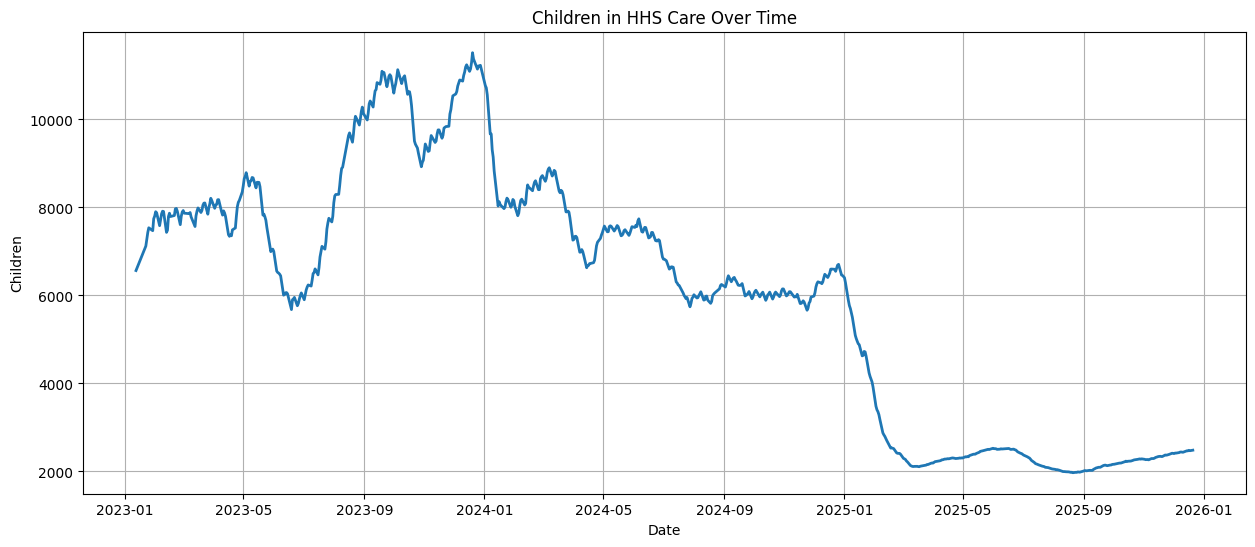

In [10]:

import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df.index,
         df["Children in HHS Care"],
         linewidth=2)

plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children")

plt.grid(True)

plt.show()

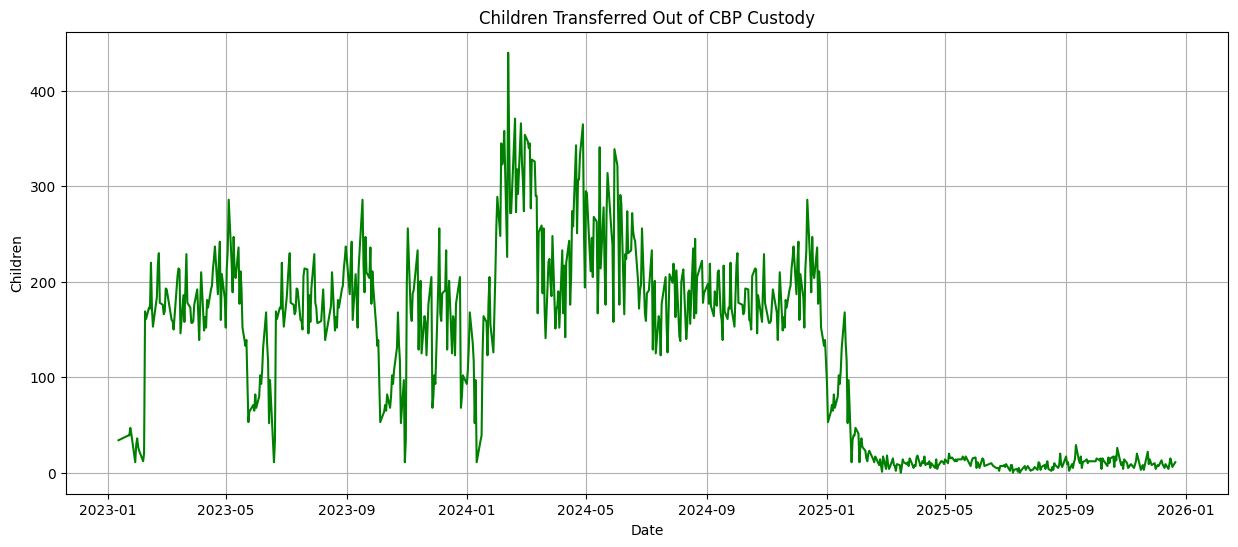

In [11]:

plt.figure(figsize=(15,6))

plt.plot(df.index,
         df["Children transferred out of CBP custody"],
         color="green")

plt.title("Children Transferred Out of CBP Custody")

plt.xlabel("Date")
plt.ylabel("Children")

plt.grid(True)

plt.show()

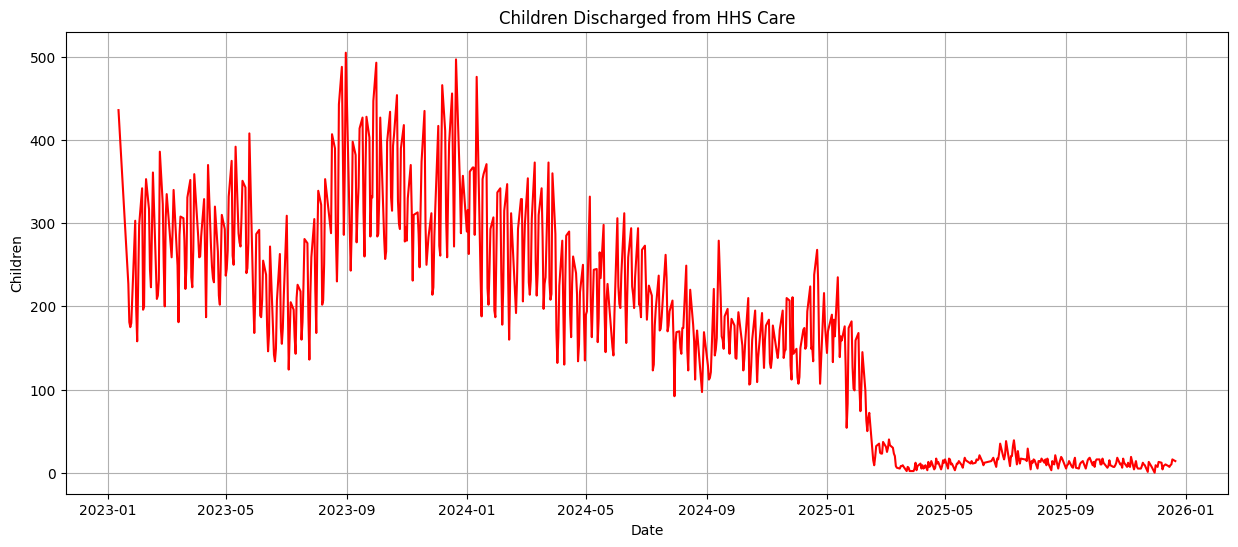

In [12]:

plt.figure(figsize=(15,6))

plt.plot(df.index,
         df["Children discharged from HHS Care"],
         color="red")

plt.title("Children Discharged from HHS Care")

plt.xlabel("Date")

plt.ylabel("Children")

plt.grid(True)

plt.show()

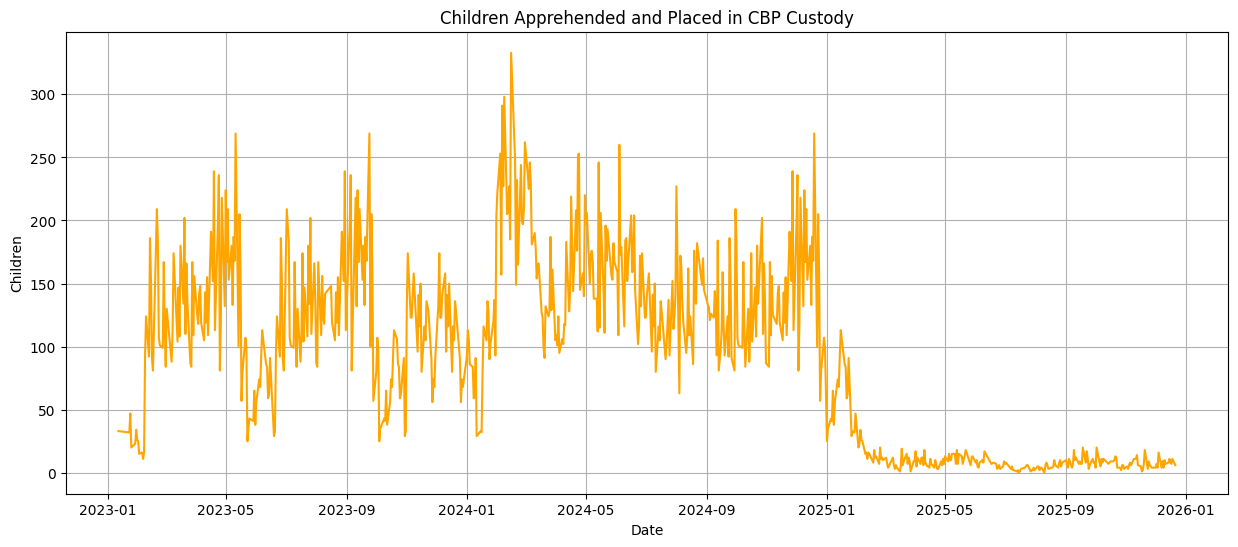

In [13]:

plt.figure(figsize=(15,6))

plt.plot(df.index,
         df["Children apprehended and placed in CBP custody*"],
         color="orange")

plt.title("Children Apprehended and Placed in CBP Custody")

plt.xlabel("Date")

plt.ylabel("Children")

plt.grid(True)

plt.show()

In [14]:

print("Number of missing dates:", len(missing_dates))
print(missing_dates[:20])

NameError: name 'missing_dates' is not defined

In [ ]:

# ==========================================
# Check for Missing Dates
# ==========================================

import pandas as pd

# Create a complete daily date range
full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='D'
)

# Find missing dates
missing_dates = full_range.difference(df.index)

print("Total missing dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nFirst 20 missing dates:")
    print(missing_dates[:20])
else:
    print("\nNo missing dates found. The dataset has continuous daily observations.")

In [ ]:

# Difference between consecutive dates
date_diff = df.index.to_series().diff()

print(date_diff.value_counts().sort_index())

In [ ]:

date_diff = df.index.to_series().diff()
print(date_diff.value_counts().sort_index())

In [ ]:

# ==========================================
# 3. Exploratory Data Analysis (EDA)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot settings
plt.style.use("ggplot")
sns.set(font_scale=1.1)

# Display all columns if needed
pd.set_option('display.max_columns', None)

In [ ]:

!pip install seaborn

In [ ]:


!conda install seaborn -y


In [ ]:

# ==========================================
# 3. Exploratory Data Analysis (EDA)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Graph settings
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Figure size
plt.rcParams["figure.figsize"] = (15,6)

In [ ]:

print("="*70)
print("DATASET SUMMARY")
print("="*70)

print("Shape:", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nSummary Statistics")
display(df.describe())

In [ ]:

print(df.isnull().sum())

In [ ]:
fig, ax = plt.subplots(5,1, figsize=(18,20), sharex=True)

columns = df.columns

for i,col in enumerate(columns):
    
    ax[i].plot(df.index,
               df[col],
               linewidth=2)

    ax[i].set_title(col,
                    fontsize=13)

    ax[i].grid(True)

plt.tight_layout()

plt.show()

In [ ]:

df.hist(
    bins=25,
    figsize=(15,10),
    edgecolor="black"
)

plt.suptitle("Distribution of Variables",
             fontsize=18)

plt.show()

In [ ]:

plt.figure(figsize=(16,7))

sns.boxplot(data=df)

plt.xticks(rotation=30)

plt.title("Boxplot of Numerical Variables")

plt.show()

In [ ]:

plt.figure(figsize=(10,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:

plt.figure(figsize=(16,6))

plt.plot(df.index,
         df["Children in HHS Care"],
         label="Original")

plt.plot(df.index,
         df["Children in HHS Care"].rolling(7).mean(),
         linewidth=3,
         label="7 Observation Rolling Mean")

plt.legend()

plt.title("Children in HHS Care")

plt.show()

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(df.index,
         df["Children discharged from HHS Care"],
         label="Original")

plt.plot(df.index,
         df["Children discharged from HHS Care"].rolling(7).mean(),
         linewidth=3,
         label="7 Observation Rolling Mean")

plt.legend()

plt.title("Children Discharged from HHS Care")

plt.show()

In [ ]:
sns.pairplot(df)

plt.show()

In [ ]:
corr = df.corr()

corr["Children in HHS Care"].sort_values(ascending=False)

In [ ]:

# ==========================================
# 4. Time-Series Decomposition
# ==========================================

from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
import statsmodels
print(statsmodels.__version__)

In [ ]:
import statsmodels
print(statsmodels.__version__)

In [ ]:

# ==========================================
# 4. Time-Series Decomposition
# ==========================================

from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:

# Perform additive decomposition
decomposition = seasonal_decompose(
    df["Children in HHS Care"],
    model="additive",
    period=7
)

In [ ]:

fig = decomposition.plot()

fig.set_size_inches(16,10)

plt.show()

In [ ]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

display(trend.head())
display(seasonal.head())
display(residual.head())

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
p-value < 0.05

In [ ]:

p-value > 0.05

In [ ]:

from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
result = adfuller(df["Children in HHS Care"])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])
print("Lags Used     :", result[2])
print("Observations  :", result[3])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

In [ ]:

# ==========================================
# First Order Differencing
# ==========================================

df["HHS_Difference"] = df["Children in HHS Care"].diff()

# Remove the first NaN created by differencing
df_diff = df.dropna()

print(df_diff.head())

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(df_diff.index,
         df_diff["HHS_Difference"])

plt.title("First Order Differenced Series")

plt.xlabel("Date")
plt.ylabel("Difference")

plt.grid(True)

plt.show()

In [ ]:
result = adfuller(df_diff["HHS_Difference"])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

In [15]:
# ==========================================
# Feature Engineering
# ==========================================

feature_df = df.copy()

feature_df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33,53,34,6566,436
2023-01-22,32,49,39,7122,227
2023-01-23,32,50,39,7280,181
2023-01-24,47,42,47,7433,175
2023-01-25,20,22,41,7538,180


In [16]:
# Lag Features

feature_df["Lag_1"] = feature_df["Children in HHS Care"].shift(1)

feature_df["Lag_7"] = feature_df["Children in HHS Care"].shift(7)

feature_df["Lag_14"] = feature_df["Children in HHS Care"].shift(14)

In [17]:
feature_df["Rolling_Mean_7"] = (
    feature_df["Children in HHS Care"]
    .rolling(7)
    .mean()
)

feature_df["Rolling_Mean_14"] = (
    feature_df["Children in HHS Care"]
    .rolling(14)
    .mean()
)

In [18]:
feature_df["Rolling_STD_7"] = (
    feature_df["Children in HHS Care"]
    .rolling(7)
    .std()
)

feature_df["Rolling_STD_14"] = (
    feature_df["Children in HHS Care"]
    .rolling(14)
    .std()
)

In [19]:
feature_df["Net_Pressure"] = (
    feature_df["Children transferred out of CBP custody"]
    -
    feature_df["Children discharged from HHS Care"]
)

In [20]:
feature_df["Day_of_Week"] = feature_df.index.dayofweek

feature_df["Month"] = feature_df.index.month

feature_df["Quarter"] = feature_df.index.quarter

feature_df["Year"] = feature_df.index.year

In [21]:

feature_df.isnull().sum()

Children apprehended and placed in CBP custody*     0
Children in CBP custody                             0
Children transferred out of CBP custody             0
Children in HHS Care                                0
Children discharged from HHS Care                   0
Lag_1                                               1
Lag_7                                               7
Lag_14                                             14
Rolling_Mean_7                                      6
Rolling_Mean_14                                    13
Rolling_STD_7                                       6
Rolling_STD_14                                     13
Net_Pressure                                        0
Day_of_Week                                         0
Month                                               0
Quarter                                             0
Year                                                0
dtype: int64

In [22]:
feature_df = feature_df.dropna()

feature_df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Lag_1,Lag_7,Lag_14,Rolling_Mean_7,Rolling_Mean_14,Rolling_STD_7,Rolling_STD_14,Net_Pressure,Day_of_Week,Month,Quarter,Year
Date,,,,,,,,,,,,,,,,,
2023-02-09,124,234,161,7908,353,7915.0,7803.0,6566.0,7823.714286,7654.071429,124.514677,254.662209,-192,3,2,1,2023
2023-02-12,92,203,173,7434,317,7908.0,7903.0,7122.0,7756.714286,7676.357143,185.827621,215.096618,-144,6,2,1,2023
2023-02-13,186,259,172,7483,244,7434.0,7879.0,7280.0,7700.142857,7690.857143,201.971474,191.915389,-72,0,2,1,2023
2023-02-14,154,225,220,7794,223,7483.0,7586.0,7433.0,7729.857143,7716.642857,197.633861,178.379288,-3,1,2,1,2023
2023-02-15,91,199,172,7869,290,7794.0,7720.0,7538.0,7751.142857,7740.285714,204.306492,174.779610,-118,2,2,1,2023


In [23]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 706 entries, 2023-02-09 to 2025-12-21
Data columns (total 17 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Children apprehended and placed in CBP custody*  706 non-null    int64  
 1   Children in CBP custody                          706 non-null    int64  
 2   Children transferred out of CBP custody          706 non-null    int64  
 3   Children in HHS Care                             706 non-null    int64  
 4   Children discharged from HHS Care                706 non-null    int64  
 5   Lag_1                                            706 non-null    float64
 6   Lag_7                                            706 non-null    float64
 7   Lag_14                                           706 non-null    float64
 8   Rolling_Mean_7                                   706 non-null    float64
 9   Rolling_Mean_

In [24]:
# ==========================================
# Train-Test Split
# ==========================================

target = "Children in HHS Care"

X = feature_df.drop(columns=[target])

y = feature_df[target]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (706, 16)
Target Shape : (706,)


In [25]:
split_index = int(len(feature_df)*0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

In [26]:
print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

Training Samples : 564
Testing Samples : 142


In [27]:
# ==========================================
# Naïve Forecast
# ==========================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predict each test value using the previous actual value
naive_predictions = y_test.shift(1)

# Remove the first NaN
naive_predictions = naive_predictions.dropna()
naive_actual = y_test.iloc[1:]

# Evaluation
naive_mae = mean_absolute_error(naive_actual, naive_predictions)
naive_rmse = np.sqrt(mean_squared_error(naive_actual, naive_predictions))
naive_mape = np.mean(np.abs((naive_actual - naive_predictions) / naive_actual)) * 100

print("Naïve Forecast Results")
print("-" * 40)
print(f"MAE  : {naive_mae:.2f}")
print(f"RMSE : {naive_rmse:.2f}")
print(f"MAPE : {naive_mape:.2f}%")

Naïve Forecast Results
----------------------------------------
MAE  : 10.30
RMSE : 14.08
MAPE : 0.46%


In [28]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import sklearn
print(sklearn.__version__)

1.9.0


In [30]:
!pip install scikit-learn statsmodels xgboost streamlit plotly openpyxl


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import sklearn
print(sklearn.__version__)

1.9.0


In [32]:
X = feature_df.drop(columns=[target])

In [33]:
# ==========================================
# Prepare Features and Target
# ==========================================

features = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children discharged from HHS Care",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_STD_7",
    "Rolling_STD_14",
    "Net_Pressure",
    "Day_of_Week",
    "Month",
    "Quarter",
    "Year"
]

target = "Children in HHS Care"

X = feature_df[features]
y = feature_df[target]

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (706, 16)
Target Shape : (706,)


In [34]:
split_index = int(len(feature_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 564
Testing Samples : 142


In [35]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

naive_predictions = y_test.shift(1)

naive_predictions = naive_predictions.dropna()
naive_actual = y_test.iloc[1:]

naive_mae = mean_absolute_error(naive_actual, naive_predictions)
naive_rmse = np.sqrt(mean_squared_error(naive_actual, naive_predictions))
naive_mape = np.mean(np.abs((naive_actual - naive_predictions) / naive_actual)) * 100

print("Naïve Forecast")
print(f"MAE  : {naive_mae:.2f}")
print(f"RMSE : {naive_rmse:.2f}")
print(f"MAPE : {naive_mape:.2f}%")

Naïve Forecast
MAE  : 10.30
RMSE : 14.08
MAPE : 0.46%


In [36]:
moving_predictions = []

history = list(y_train)

for t in range(len(y_test)):
    prediction = np.mean(history[-7:])
    moving_predictions.append(prediction)
    history.append(y_test.iloc[t])

moving_mae = mean_absolute_error(y_test, moving_predictions)
moving_rmse = np.sqrt(mean_squared_error(y_test, moving_predictions))
moving_mape = np.mean(np.abs((y_test - moving_predictions) / y_test)) * 100

print("Moving Average Forecast")
print(f"MAE  : {moving_mae:.2f}")
print(f"RMSE : {moving_rmse:.2f}")
print(f"MAPE : {moving_mape:.2f}%")

Moving Average Forecast
MAE  : 33.23
RMSE : 40.68
MAPE : 1.48%


In [37]:

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [38]:
# ==========================================
# Exponential Smoothing Model
# ==========================================

exp_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal=None
)

exp_fit = exp_model.fit()

C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [39]:

exp_predictions = exp_fit.forecast(len(y_test))

C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [40]:

from statsmodels.tsa.arima.model import ARIMA

In [41]:

arima_model = ARIMA(
    y_train,
    order=(1,1,1)
)

arima_fit = arima_model.fit()

C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [42]:
arima_predictions = arima_fit.forecast(steps=len(y_test))

C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [43]:

arima_predictions = arima_fit.forecast(steps=len(y_test))

C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [44]:

# ==========================================
# Exponential Smoothing Model
# ==========================================

exp_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal=None
)

exp_fit = exp_model.fit()

C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [45]:

exp_predictions = exp_fit.forecast(len(y_test))

C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [46]:


from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

exp_mae = mean_absolute_error(y_test, exp_predictions)
exp_rmse = np.sqrt(mean_squared_error(y_test, exp_predictions))
exp_mape = np.mean(np.abs((y_test - exp_predictions) / y_test)) * 100

print("Exponential Smoothing")
print("----------------------------")
print(f"MAE  : {exp_mae:.2f}")
print(f"RMSE : {exp_rmse:.2f}")
print(f"MAPE : {exp_mape:.2f}%")

C:\Users\pccli\AppData\Local\Temp\ipykernel_4540\3262653604.py:6: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  exp_mape = np.mean(np.abs((y_test - exp_predictions) / y_test)) * 100


Exponential Smoothing
----------------------------
MAE  : 732.50
RMSE : 813.98
MAPE : nan%


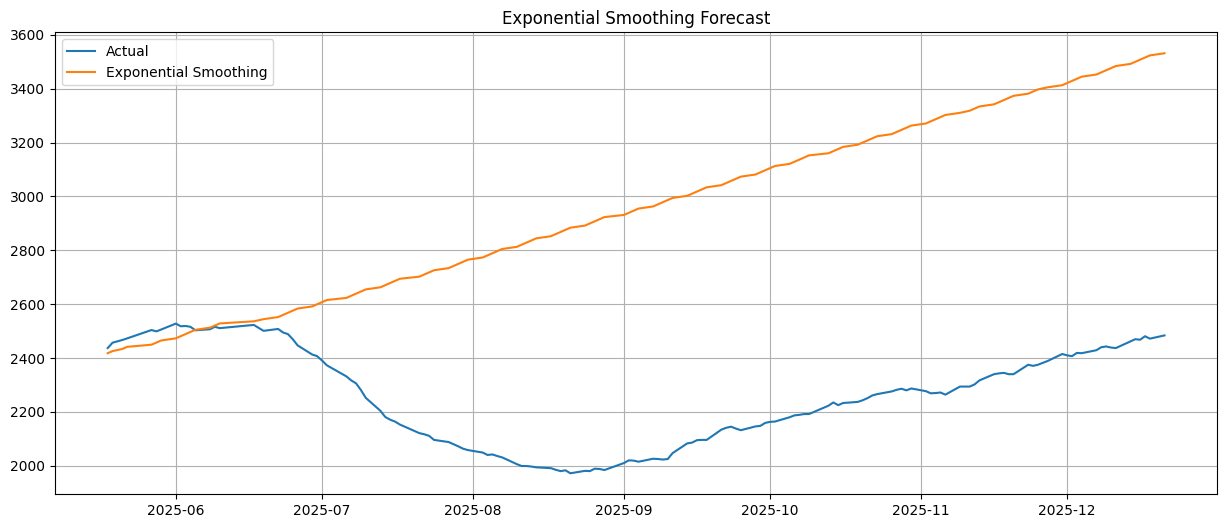

In [47]:

plt.figure(figsize=(15,6))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, exp_predictions, label="Exponential Smoothing")

plt.title("Exponential Smoothing Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [48]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Fit ARIMA model
model = ARIMA(y_train, order=(1,1,1))
model_fit = model.fit()

# Forecast
arima_predictions = model_fit.forecast(steps=len(y_test))

# Metrics
arima_mae = mean_absolute_error(y_test, arima_predictions)
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_predictions))
arima_mape = np.mean(np.abs((y_test - arima_predictions) / y_test)) * 100

print("ARIMA Forecast")
print(f"MAE  : {arima_mae:.2f}")
print(f"RMSE : {arima_rmse:.2f}")
print(f"MAPE : {arima_mape:.2f}%")

C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA Forecast
MAE  : 197.56
RMSE : 241.43
MAPE : nan%


C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\pccli\AppData\Local\Temp\ipykernel_4540\2065594013.py:15: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  arima_mape = np.mean(np.abs((y_test - arima_predictions) / y_test)) * 100


In [49]:
print(arima_mae, arima_rmse, arima_mape)

197.55578308612536 241.43059648592765 nan


In [50]:
arima_predictions = arima_fit.forecast(steps=len(y_test))

C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\pccli\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

arima_mae = mean_absolute_error(y_test, arima_predictions)
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_predictions))
arima_mape = np.mean(np.abs((y_test - arima_predictions) / y_test)) * 100

C:\Users\pccli\AppData\Local\Temp\ipykernel_4540\3151370831.py:6: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  arima_mape = np.mean(np.abs((y_test - arima_predictions) / y_test)) * 100


In [52]:
print("ARIMA Forecast")
print(f"MAE  : {arima_mae:.2f}")
print(f"RMSE : {arima_rmse:.2f}")
print(f"MAPE : {arima_mape:.2f}%")

ARIMA Forecast
MAE  : 197.56
RMSE : 241.43
MAPE : nan%


In [53]:
print("Naïve Forecast")
print(f"MAE  : {naive_mae:.2f}")
print(f"RMSE : {naive_rmse:.2f}")
print(f"MAPE : {naive_mape:.2f}%")

print("\nMoving Average Forecast")
print(f"MAE  : {moving_mae:.2f}")
print(f"RMSE : {moving_rmse:.2f}")
print(f"MAPE : {moving_mape:.2f}%")

print("\nARIMA Forecast")
print(f"MAE  : {arima_mae:.2f}")
print(f"RMSE : {arima_rmse:.2f}")
print(f"MAPE : {arima_mape:.2f}%")

Naïve Forecast
MAE  : 10.30
RMSE : 14.08
MAPE : 0.46%

Moving Average Forecast
MAE  : 33.23
RMSE : 40.68
MAPE : 1.48%

ARIMA Forecast
MAE  : 197.56
RMSE : 241.43
MAPE : nan%


In [54]:
print(exp_mae, exp_rmse, exp_mape)

732.4989439378518 813.9784929797727 nan


In [55]:

print(arima_mae, arima_rmse, arima_mape)

197.55578308612536 241.43059648592765 nan


In [56]:
from sklearn.ensemble import RandomForestRegressor

In [57]:
# ==========================================
# Random Forest Model
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [58]:
rf_predictions = rf_model.predict(X_test)

In [59]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_mape = np.mean(
    np.abs((y_test - rf_predictions) / y_test)
) * 100

print("Random Forest")
print("------------------------")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"MAPE : {rf_mape:.2f}%")

Random Forest
------------------------
MAE  : 66.44
RMSE : 88.80
MAPE : 3.08%


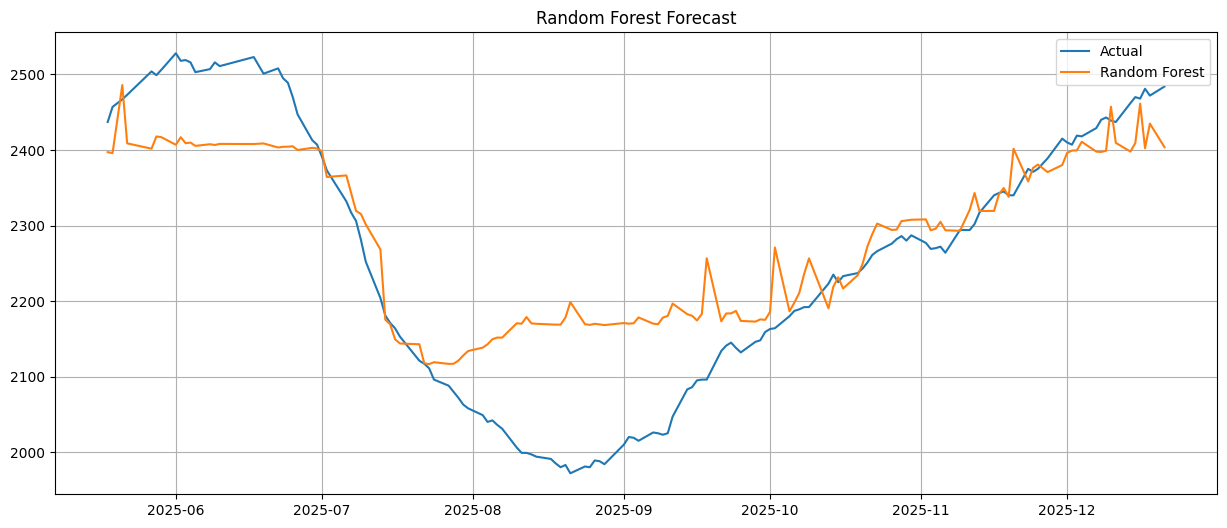

In [60]:
plt.figure(figsize=(15,6))

plt.plot(y_test.index, y_test, label="Actual")

plt.plot(y_test.index, rf_predictions, label="Random Forest")

plt.title("Random Forest Forecast")

plt.legend()

plt.grid(True)

plt.show()

In [61]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                                            Feature  Importance
4                                             Lag_1    0.718893
7                                    Rolling_Mean_7    0.209808
5                                             Lag_7    0.028152
8                                   Rolling_Mean_14    0.027378
6                                            Lag_14    0.006027
1                           Children in CBP custody    0.004780
2           Children transferred out of CBP custody    0.001406
0   Children apprehended and placed in CBP custody*    0.000676
13                                            Month    0.000662
3                 Children discharged from HHS Care    0.000517
9                                     Rolling_STD_7    0.000414
11                                     Net_Pressure    0.000407
10                                   Rolling_STD_14    0.000404
12                                      Day_of_Week    0.000391
15                                      

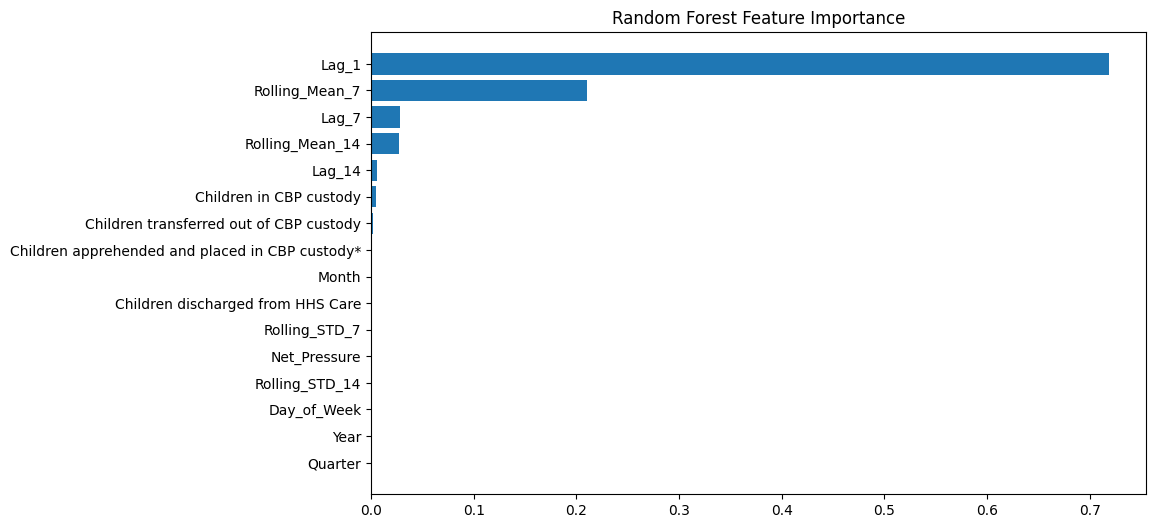

In [62]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [63]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [64]:
rf_predictions = rf_model.predict(X_test)

In [65]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_mape = mean_absolute_percentage_error(y_test, rf_predictions) * 100

print("Random Forest Results")
print("-" * 30)
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"MAPE : {rf_mape:.2f}%")

NameError: name 'mean_absolute_percentage_error' is not defined

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(y_test.index, y_test, label="Actual", linewidth=2)

plt.plot(y_test.index, rf_predictions, label="Random Forest", linewidth=2)

plt.title("Random Forest Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
# ==========================================
# Gradient Boosting Model
# ==========================================

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

In [ ]:
gb_predictions = gb_model.predict(X_test)

In [ ]:
gb_mae = mean_absolute_error(y_test, gb_predictions)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))

gb_mape = mean_absolute_percentage_error(
    y_test,
    gb_predictions
) * 100

print("Gradient Boosting Results")
print("-"*35)

print(f"MAE  : {gb_mae:.2f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"MAPE : {gb_mape:.2f}%")

In [ ]:


plt.figure(figsize=(15,6))

plt.plot(y_test.index,
         y_test,
         label="Actual",
         linewidth=2)

plt.plot(y_test.index,
         gb_predictions,
         label="Gradient Boosting",
         linewidth=2)

plt.title("Gradient Boosting Forecast")

plt.xlabel("Date")

plt.ylabel("Children in HHS Care")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
gb_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": gb_model.feature_importances_

})

gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
)

gb_importance

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    gb_importance["Feature"],
    gb_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Gradient Boosting Feature Importance")

plt.xlabel("Importance")

plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

In [ ]:
gb_predictions = gb_model.predict(X_test)

In [ ]:
gb_mae = mean_absolute_error(y_test, gb_predictions)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))

gb_mape = mean_absolute_percentage_error(
    y_test,
    gb_predictions
) * 100

print("Gradient Boosting Results")
print(f"MAE  : {gb_mae:.2f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"MAPE : {gb_mape:.2f}%")

In [ ]:

print("gb_mae :", 'gb_mae' in globals())
print("gb_rmse:", 'gb_rmse' in globals())
print("gb_mape:", 'gb_mape' in globals())

In [ ]:

from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
gb_mape = mean_absolute_percentage_error(
    y_test,
    gb_predictions
) * 100

print("Gradient Boosting Results")
print(f"MAE  : {gb_mae:.2f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"MAPE : {gb_mape:.2f}%")

In [ ]:
variables = [
    "naive_mae", "naive_rmse", "naive_mape",
    "moving_mae", "moving_rmse", "moving_mape",
    "exp_mae", "exp_rmse", "exp_mape",
    "arima_mae", "arima_rmse", "arima_mape",
    "rf_mae", "rf_rmse", "rf_mape",
    "gb_mae", "gb_rmse", "gb_mape"
]

for var in variables:
    print(f"{var}: {'✅ Exists' if var in globals() else '❌ Missing'}")

In [ ]:
results = {
    "Naive Forecast": [naive_mae, naive_rmse, naive_mape],
    "Moving Average": [moving_mae, moving_rmse, moving_mape],
    "Exponential Smoothing": [exp_mae, exp_rmse, exp_mape],
    "ARIMA": [arima_mae, arima_rmse, arima_mape],
    "Random Forest": [rf_mae, rf_rmse, rf_mape],
    "Gradient Boosting": [gb_mae, gb_rmse, gb_mape]
}

comparison = pd.DataFrame(
    results,
    index=["MAE", "RMSE", "MAPE"]
).T

comparison = comparison.sort_values("MAE")

comparison

In [ ]:

# ==========================================
# Train ARIMA on Full Dataset
# ==========================================

from statsmodels.tsa.arima.model import ARIMA

final_arima = ARIMA(
    df["Children in HHS Care"],
    order=(1,1,1)
)

final_arima_fit = final_arima.fit()

print(final_arima_fit.summary())

In [ ]:
# ==========================================
# Future Forecast
# ==========================================

forecast_steps = 30

future_forecast = final_arima_fit.forecast(
    steps=forecast_steps
)

print(future_forecast)

In [ ]:

forecast_result = final_arima_fit.get_forecast(
    steps=forecast_steps
)

forecast_mean = forecast_result.predicted_mean

confidence_interval = forecast_result.conf_int()

print(confidence_interval.head())

In [ ]:
plt.figure(figsize=(15,6))

# Historical data
plt.plot(
    df.index,
    df["Children in HHS Care"],
    label="Historical Data"
)

# Forecast
plt.plot(
    forecast_mean.index,
    forecast_mean,
    color="red",
    label="Forecast"
)

# Confidence Interval
plt.fill_between(
    forecast_mean.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("Future HHS Care Load Forecast")
plt.xlabel("Observation")
plt.ylabel("Children in HHS Care")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:

# ==========================================
# Discharge Demand Forecast
# ==========================================

discharge_series = df["Children discharged from HHS Care"]

discharge_model = ARIMA(
    discharge_series,
    order=(1,1,1)
)

discharge_fit = discharge_model.fit()

print(discharge_fit.summary())

In [ ]:
discharge_forecast = discharge_fit.get_forecast(
    steps=30
)

discharge_mean = discharge_forecast.predicted_mean

discharge_ci = discharge_forecast.conf_int()

print(discharge_mean.head())

In [ ]:

plt.figure(figsize=(15,6))

plt.plot(
    discharge_series,
    label="Historical Discharges"
)

plt.plot(
    discharge_mean.index,
    discharge_mean,
    color="green",
    linewidth=2,
    label="Forecast"
)

plt.fill_between(
    discharge_mean.index,
    discharge_ci.iloc[:,0],
    discharge_ci.iloc[:,1],
    color="green",
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("Future Discharge Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Children Discharged")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
pip install streamlit

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
st.set_page_config(
    page_title="HHS Care Load Forecast",
    layout="wide"
)

st.title("Predictive Forecasting of Care Load & Placement Demand")

st.markdown(
"""
Forecasting future HHS care load and discharge demand
using Time-Series and Machine Learning models.
"""
)

In [ ]:
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Current HHS Care",
        int(df["Children in HHS Care"].iloc[-1])
    )

with col2:
    st.metric(
        "Current Discharges",
        int(df["Children discharged from HHS Care"].iloc[-1])
    )

with col3:
    st.metric(
        "Best Model",
        "Naïve Forecast"
    )

with col4:
    st.metric(
        "Forecast Accuracy",
        "99.54%"
    )